In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Lib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import random
import kagglehub
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2

import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


# Config


In [31]:
DATASET = "electraawais/cityscape-dataset"

CITYSCAPES_CLASSES = ["road", "sidewalk", "building", "wall", "fence",
                      "pole", "traffic light", "traffic sign", "vegetation",
                      "terrain", "sky", "person", "rider", "car",
                      "truck", "bus", "train", "motorcycle", "bicycle"]
NUM_CLASSES = len(CITYSCAPES_CLASSES)
IGNORE_INDEX = 255

LABELID_TO_TRAINID = {
    0: 255,
    1: 255,
    2: 255,
    3: 255,
    4: 255,
    5: 255,
    6: 255,
    7: 0,     # road
    8: 1,     # sidewalk
    9: 255,
    10: 255,
    11: 2,    # building
    12: 3,    # wall
    13: 4,    # fence
    14: 255,
    15: 255,
    16: 255,
    17: 5,    # pole
    18: 255,
    19: 6,    # traffic light
    20: 7,    # traffic sign
    21: 8,    # vegetation
    22: 9,    # terrain
    23: 10,   # sky
    24: 11,   # person
    25: 12,   # rider
    26: 13,   # car
    27: 14,   # truck
    28: 15,   # bus
    29: 255,
    30: 255,
    31: 16,   # train
    32: 17,   # motorcycle
    33: 18,   # bicycle
    255: 255
}

CITYSCAPES_COLORS = np.array([
    [128, 64, 128],    # road
    [244, 35, 232],    # sidewalk
    [70, 70, 70],      # building
    [102, 102, 156],   # wall
    [190, 153, 153],   # fence
    [153, 153, 153],   # pole
    [250, 170, 30],    # traffic light
    [220, 220, 0],     # traffic sign
    [107, 142, 35],    # vegetation
    [152, 251, 152],   # terrain
    [70, 130, 180],    # sky
    [220, 20, 60],     # person
    [255, 0, 0],       # rider
    [0, 0, 142],       # car
    [0, 0, 70],        # truck
    [0, 60, 100],      # bus
    [0, 80, 100],      # train
    [0, 0, 230],       # motorcycle
    [119, 11, 32],     # bicycle
], dtype=np.uint8)

IMAGE_HEIGHT = 512
IMAGE_WIDTH = 512

BATCH_SIZE = 2

RANDOMSEED = 42

# Load Data

In [4]:
path = kagglehub.dataset_download(DATASET)

print("Path to dataset files:", path)

os.listdir(path)

Using Colab cache for faster access to the 'cityscape-dataset' dataset.
Path to dataset files: /kaggle/input/cityscape-dataset


['Fine Annotations', 'Cityscape Dataset']

In [5]:
image_root = os.path.join(path, 'Cityscape Dataset', 'leftImg8bit')
mask_root = os.path.join(path, 'Fine Annotations', 'gtFine')

print("Image root:", image_root)
print("Mask root:", mask_root)


Image root: /kaggle/input/cityscape-dataset/Cityscape Dataset/leftImg8bit
Mask root: /kaggle/input/cityscape-dataset/Fine Annotations/gtFine


## Pair image-mask

In [6]:
def get_cityscapes_pairs(left_root, gt_root, split="train"):
    left_split_path = os.path.join(left_root, split)
    gt_split_path = os.path.join(gt_root, split)

    image_paths = []

    for root, _, files in os.walk(left_split_path):
        for file in files:
            if file.endswith("_leftImg8bit.png"):
                image_paths.append(os.path.join(root, file))
    image_paths.sort()

    trainid_masks = {}
    labelid_masks = {}

    for root, _, files in os.walk(gt_split_path):
        for file in files:
            if file.endswith("_gtFine_labelTrainIds.png"):
                trainid_masks[os.path.basename(file)] = os.path.join(root, file)
            elif file.endswith("_gtFine_labelIds.png"):
                labelid_masks[os.path.basename(file)] = os.path.join(root, file)

    pairs = []

    for img_path_str in image_paths:
        img_name = os.path.basename(img_path_str)

        trainid_name = img_name.replace(
            "_leftImg8bit.png",
            "_gtFine_labelTrainIds.png"
        )

        labelid_name = img_name.replace(
            "_leftImg8bit.png",
            "_gtFine_labelIds.png"
        )

        if trainid_name in trainid_masks:
            pairs.append((img_path_str, trainid_masks[trainid_name], "trainId"))
        elif labelid_name in labelid_masks:
            pairs.append((img_path_str, labelid_masks[labelid_name], "labelId"))
        else:
            print(f"Missing mask for: {img_path_str}")

    return pairs


In [7]:
train_pairs = get_cityscapes_pairs(image_root, mask_root, split="train")
val_pairs = get_cityscapes_pairs(image_root, mask_root, split="val")

print("Train pairs:", len(train_pairs))
print("Val pairs:", len(val_pairs))

print("\nExample pair:")
print(train_pairs[70])

Train pairs: 2975
Val pairs: 500

Example pair:
('/kaggle/input/cityscape-dataset/Cityscape Dataset/leftImg8bit/train/aachen/aachen_000070_000019_leftImg8bit.png', '/kaggle/input/cityscape-dataset/Fine Annotations/gtFine/train/aachen/aachen_000070_000019_gtFine_labelIds.png', 'labelId')


## Labelid to Trainid

In [10]:
def convert_labelid_to_trainid(mask):
    train_mask = np.ones_like(mask, dtype=np.uint8) * IGNORE_INDEX

    for label_id, train_id in LABELID_TO_TRAINID.items():
        train_mask[mask == label_id] = train_id

    return train_mask

In [12]:
sample_img_path, sample_mask_path, mask_type = train_pairs[10]

image = Image.open(sample_img_path).convert("RGB")
mask = Image.open(sample_mask_path)

image = np.array(image)
mask = np.array(mask)

if mask_type == "labelId":
    mask = convert_labelid_to_trainid(mask)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask type:", mask_type)
print("Mask unique values:", np.unique(mask))

Image shape: (1024, 2048, 3)
Mask shape: (1024, 2048)
Mask type: labelId
Mask unique values: [  0   1   2   4   5   6   7   8   9  10  11  12  13  17  18 255]


In [13]:
def check_mask_values(mask):
    valid_values = set(list(range(NUM_CLASSES)) + [IGNORE_INDEX])
    mask_values = set(np.unique(mask).tolist())

    invalid_values = mask_values - valid_values

    print("Mask values:", sorted(mask_values))

    if len(invalid_values) > 0:
        print("Invalid values:", invalid_values)
        raise ValueError("Mask có class id không hợp lệ.")

    print("Mask is valid.")


check_mask_values(mask)

Mask values: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 17, 18, 255]
Mask is valid.


## Visualize original image

In [14]:
def decode_segmentation_mask(mask):
    h, w = mask.shape

    color_mask = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id in range(NUM_CLASSES):
        color_mask[mask == class_id] = CITYSCAPES_COLORS[class_id]

    color_mask[mask == IGNORE_INDEX] = [0, 0, 0]

    return color_mask

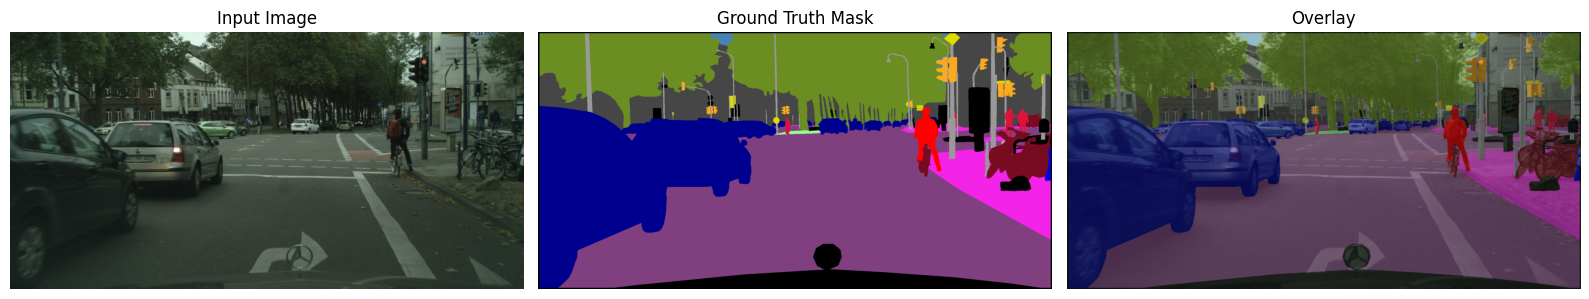

In [15]:
color_mask = decode_segmentation_mask(mask)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(color_mask)
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image)
plt.imshow(color_mask, alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

# Data augmentation

In [18]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    ),

    A.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05,
        p=0.3
    ),

    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.2
    )
    ])

# Preprocessing

In [20]:
train_transform = A.Compose([
    A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])


val_transform = A.Compose([
    A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

# Dataset

In [21]:
class CityscapesSegmentationDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path, mask_type = self.pairs[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        image = np.array(image)
        mask = np.array(mask)

        if mask.ndim != 2:
            raise ValueError(f"Mask phải là ảnh grayscale, nhưng nhận shape: {mask.shape}")

        if mask_type == "labelId":
            mask = convert_labelid_to_trainid(mask)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)

            image = transformed["image"]
            mask = transformed["mask"]

        mask = mask.long()

        return {
            "image": image,
            "mask": mask,
            "image_path": str(img_path),
            "mask_path": str(mask_path)
        }

In [22]:
train_dataset = CityscapesSegmentationDataset(
    pairs=train_pairs,
    transform=train_transform
)

val_dataset = CityscapesSegmentationDataset(
    pairs=val_pairs,
    transform=val_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Train dataset: 2975
Validation dataset: 500


In [23]:
sample = train_dataset[0]

sample_image = sample["image"]
sample_mask = sample["mask"]

print("Image tensor shape:", sample_image.shape)
print("Mask tensor shape:", sample_mask.shape)

print("Image dtype:", sample_image.dtype)
print("Mask dtype:", sample_mask.dtype)

print("Image min:", sample_image.min().item())
print("Image max:", sample_image.max().item())

print("Mask unique values:", torch.unique(sample_mask))

Image tensor shape: torch.Size([3, 512, 512])
Mask tensor shape: torch.Size([512, 512])
Image dtype: torch.float32
Mask dtype: torch.int64
Image min: -1.8610326051712036
Image max: 2.6399998664855957
Mask unique values: tensor([  0,   1,   2,   5,   7,   8,   9,  10,  11,  12,  13,  18, 255])


In [24]:
def check_tensor_mask_values(mask_tensor):
    valid_values = set(list(range(NUM_CLASSES)) + [IGNORE_INDEX])
    mask_values = set(torch.unique(mask_tensor).cpu().numpy().tolist())

    invalid_values = mask_values - valid_values

    print("Mask values:", sorted(mask_values))

    if len(invalid_values) > 0:
        print("Invalid values:", invalid_values)
        raise ValueError("Tensor mask có class id không hợp lệ.")

    print("Tensor mask is valid.")


check_tensor_mask_values(sample_mask)

Mask values: [0, 1, 2, 5, 7, 8, 9, 10, 11, 12, 13, 18, 255]
Tensor mask is valid.


# DataLoader

In [30]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 1488
Validation batches: 250


In [26]:
batch = next(iter(train_loader))

images = batch["image"]
masks = batch["mask"]

print("Batch image shape:", images.shape)
print("Batch mask shape:", masks.shape)

print("Batch image dtype:", images.dtype)
print("Batch mask dtype:", masks.dtype)

print("Image min:", images.min().item())
print("Image max:", images.max().item())

print("Mask unique values:", torch.unique(masks))

Batch image shape: torch.Size([2, 3, 512, 512])
Batch mask shape: torch.Size([2, 512, 512])
Batch image dtype: torch.float32
Batch mask dtype: torch.int64
Image min: -1.9637811183929443
Image max: 2.6399998664855957
Mask unique values: tensor([  0,   1,   2,   3,   5,   6,   7,   8,  10,  11,  12,  13,  15,  17,
        255])


# Visualize processed image

In [27]:
def denormalize_image(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = image_tensor.cpu() * std + mean
    image = image.clamp(0, 1)

    image = image.permute(1, 2, 0).numpy()

    return image

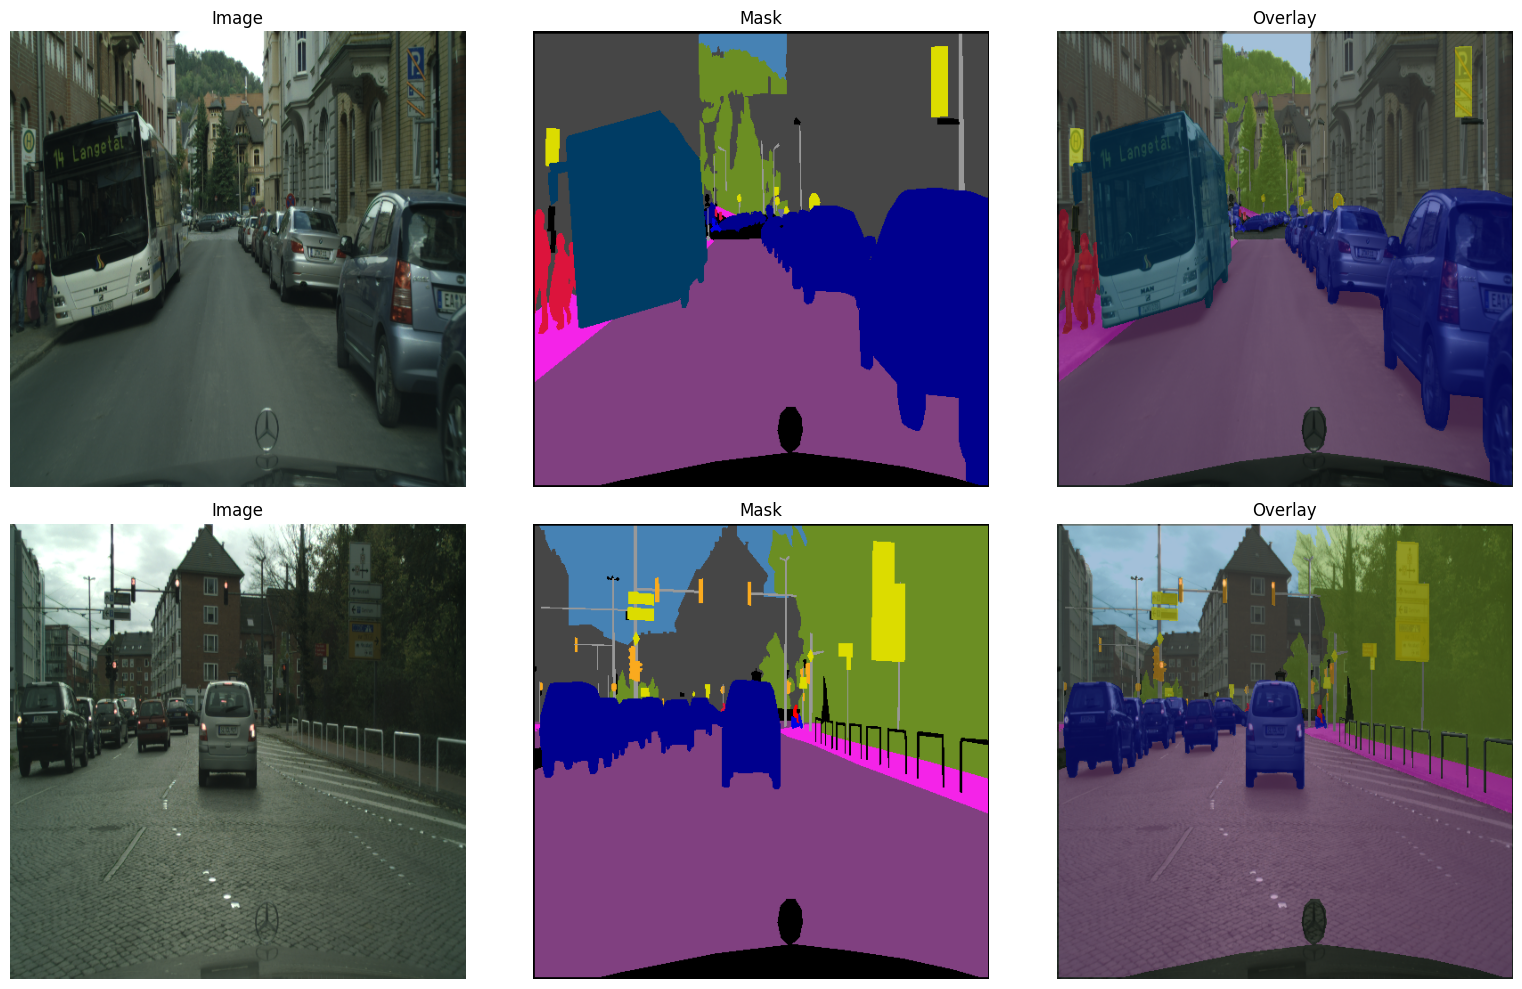

In [28]:
def visualize_batch(images, masks, num_samples=2):
    num_samples = min(num_samples, images.shape[0])

    plt.figure(figsize=(16, 5 * num_samples))

    for i in range(num_samples):
        image_np = denormalize_image(images[i])
        mask_np = masks[i].cpu().numpy()

        color_mask = decode_segmentation_mask(mask_np)

        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(image_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(color_mask)
        plt.title("Mask")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(image_np)
        plt.imshow(color_mask, alpha=0.5)
        plt.title("Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_batch(images, masks, num_samples=2)